# 🚀 Revenue Prediction dengan XGBoost
### E-Commerce Dataset — End-to-End Machine Learning Pipeline

---

**Tujuan:** Memprediksi nilai `sales` (revenue) berdasarkan fitur-fitur transaksi e-commerce.

**Tahapan:**
1. Import Library
2. Load & Eksplorasi Data (EDA)
3. Preprocessing & Feature Engineering
4. Split Data
5. Training Model XGBoost
6. Evaluasi Model
7. Feature Importance
8. Hyperparameter Tuning
9. Prediksi & Interpretasi

## Step 1 — Import Library

In [10]:
# === IMPORT LIBRARY ===
import sys
!{sys.executable} -m pip install xgboost scikit-learn pandas matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#XGBoost
import xgboost as xgb
from xgboost import XGBRegressor
import sys
print(sys.executable)
print(sys.version)


print("XGBoost berhasil dipanggil!")

# Style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']

print('✅ Library berhasil diimport!')
print(f'   XGBoost version  : {xgb.__version__}')
print(f'   Pandas  version  : {pd.__version__}')
print(f'   NumPy   version  : {np.__version__}')

c:\Users\zaki\AppData\Local\Programs\Python\Python314\python.exe
3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
XGBoost berhasil dipanggil!
✅ Library berhasil diimport!
   XGBoost version  : 3.2.0
   Pandas  version  : 2.3.3
   NumPy   version  : 2.4.3



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Load & Eksplorasi Data (EDA)

In [13]:
# === LOAD DATA ===
df = pd.read_csv('Ecommerce_Sales_Data_2024_2025 (4).csv')

print('=' * 55)
print('📦  INFORMASI DATASET')
print('=' * 55)
print(f'  Jumlah baris     : {df.shape[0]:,}')
print(f'  Jumlah kolom     : {df.shape[1]}')
print(f'  Missing values   : {df.isnull().sum().sum()}')
print('=' * 55)
df.head()

📦  INFORMASI DATASET
  Jumlah baris     : 5,000
  Jumlah kolom     : 17
  Missing values   : 0


,order_id,order_date,customer_name,region,city,category,sub_category,product_name,quantity,unit_price,discount,sales,profit,payment_mode,month,year,is_trending
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,10,2024,0
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,8,2025,0
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,11,2023,1
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI,5,2025,1
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card,1,2025,0


In [14]:
# === STATISTIK DESKRIPTIF ===
print('📊 Statistik Deskriptif — Kolom Numerik')
df.describe().round(2)

📊 Statistik Deskriptif — Kolom Numerik


,order_id,quantity,unit_price,discount,sales,profit,month,year,is_trending
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,12500.50,2.99,39760.90,10.05,106733.20,15941.75,6.48,2024.25,0.60
std,1443.52,1.41,22831.78,7.08,85108.21,14897.68,3.44,0.66,0.49
min,10001.00,1.00,222.00,0.00,264.10,19.12,1.00,2023.00,0.00
25%,11250.75,2.00,20312.25,5.00,39766.54,4892.30,4.00,2024.00,0.00
50%,12500.50,3.00,39459.50,10.00,83080.32,11108.53,6.00,2024.00,1.00
75%,13750.25,4.00,59721.75,15.00,156968.59,22467.99,9.00,2025.00,1.00
max,15000.00,5.00,79998.00,20.00,398485.00,89688.44,12.00,2025.00,1.00


In [15]:
# === TIPE DATA ===
print('🔤 Tipe Data Setiap Kolom:')
print(df.dtypes)
print()
print('📌 Unique values kolom kategorikal:')
cat_cols = ['region', 'category', 'sub_category', 'payment_mode']
for col in cat_cols:
    print(f'  {col:15s}: {df[col].nunique()} nilai → {list(df[col].unique())}')

🔤 Tipe Data Setiap Kolom:
order_id           int64
order_date        object
customer_name     object
region            object
city              object
category          object
sub_category      object
product_name      object
quantity           int64
unit_price         int64
discount           int64
sales            float64
profit           float64
payment_mode      object
month              int64
year               int64
is_trending        int64
dtype: object

📌 Unique values kolom kategorikal:
  region         : 4 nilai → ['South', 'North', 'East', 'West']
  category       : 10 nilai → ['Books', 'Groceries', 'Kitchen', 'Clothing', 'Furniture', 'Beauty', 'Home Decor', 'Electronics', 'Sports', 'Toys']
  sub_category   : 50 nilai → ['Non-Fiction', 'Rice', 'Juicer', 'Oil', 'Kids Wear', 'Chair', 'Accessories', 'Biography', 'Spices', 'Cookware Set', 'Perfume', 'Vase', "Women's Wear", 'Laptop', 'Smartwatch', 'Dumbbells', 'Textbook', 'Refrigerator', 'Wheat', 'Comics', 'Face Cream', 'Headphon

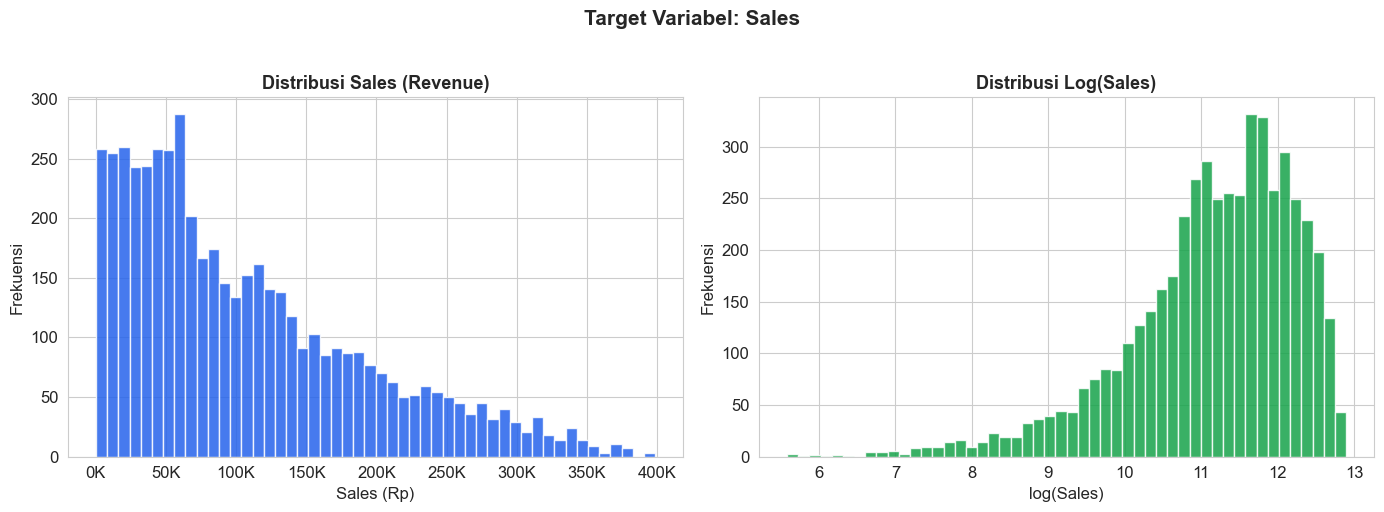


📈 Statistik Sales:
   Mean   : Rp      106,733
   Median : Rp       83,080
   Std    : Rp       85,108
   Min    : Rp          264
   Max    : Rp      398,485


In [16]:
# === DISTRIBUSI TARGET VARIABEL (SALES) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['sales'], bins=50, color='#2563EB', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Sales (Revenue)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Sales (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Log-scale untuk melihat skewness
axes[1].hist(np.log1p(df['sales']), bins=50, color='#16A34A', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Log(Sales)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('log(Sales)')
axes[1].set_ylabel('Frekuensi')

plt.suptitle('Target Variabel: Sales', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📈 Statistik Sales:')
print(f'   Mean   : Rp {df["sales"].mean():>12,.0f}')
print(f'   Median : Rp {df["sales"].median():>12,.0f}')
print(f'   Std    : Rp {df["sales"].std():>12,.0f}')
print(f'   Min    : Rp {df["sales"].min():>12,.0f}')
print(f'   Max    : Rp {df["sales"].max():>12,.0f}')

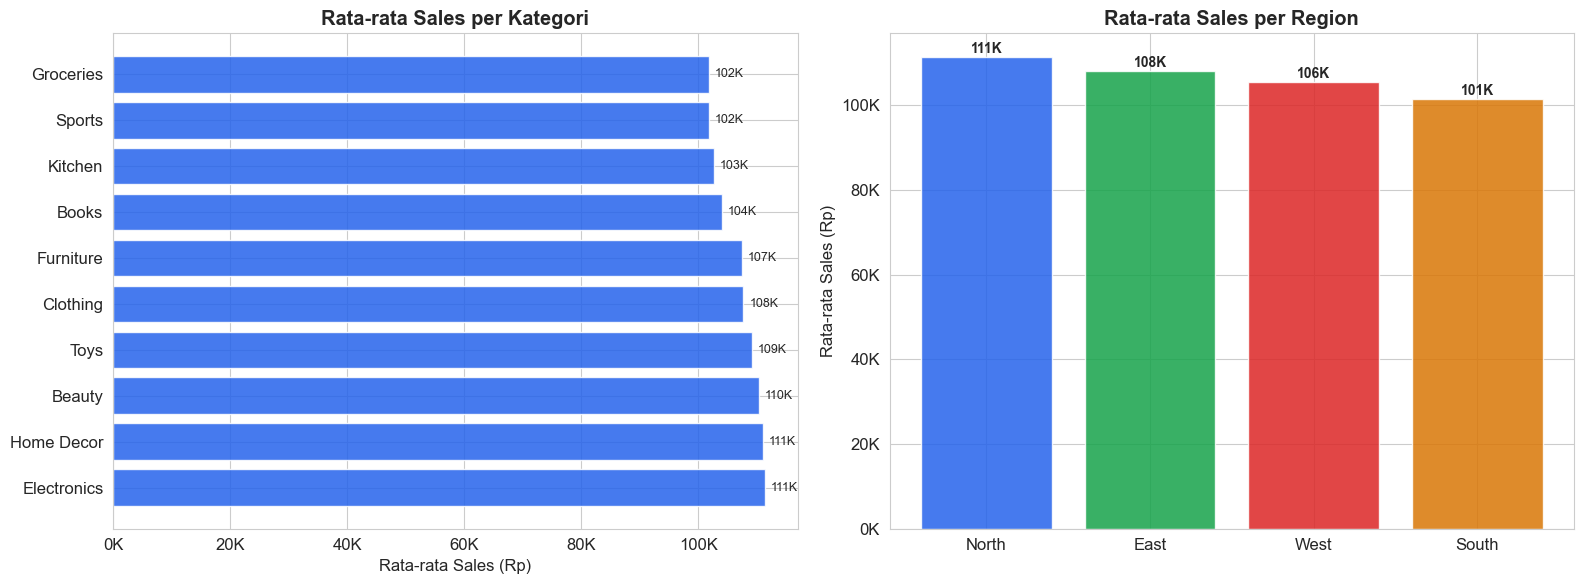

In [17]:
# === EDA — SALES PER KATEGORI ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales per Category
cat_sales = df.groupby('category')['sales'].mean().sort_values(ascending=False)
bars = axes[0].barh(cat_sales.index, cat_sales.values, color=PALETTE[0], alpha=0.85)
axes[0].set_title('Rata-rata Sales per Kategori', fontweight='bold')
axes[0].set_xlabel('Rata-rata Sales (Rp)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for bar, val in zip(bars, cat_sales.values):
    axes[0].text(val + 1000, bar.get_y() + bar.get_height()/2,
                 f'{val/1e3:.0f}K', va='center', fontsize=9)

# Sales per Region
reg_sales = df.groupby('region')['sales'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(reg_sales.index, reg_sales.values,
                    color=[PALETTE[i] for i in range(len(reg_sales))], alpha=0.85)
axes[1].set_title('Rata-rata Sales per Region', fontweight='bold')
axes[1].set_ylabel('Rata-rata Sales (Rp)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for bar, val in zip(bars2, reg_sales.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1000,
                 f'{val/1e3:.0f}K', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

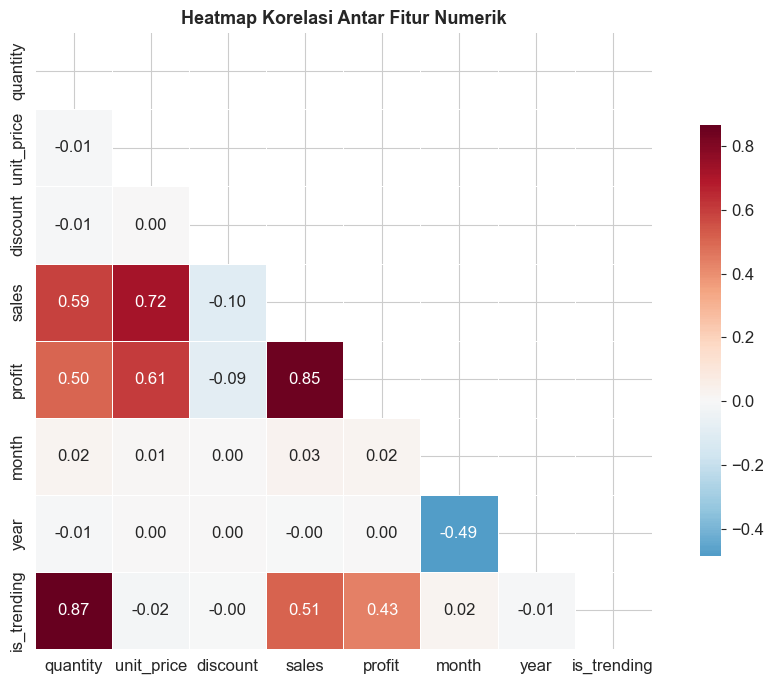


🔗 Korelasi dengan Sales:
profit         0.848792
unit_price     0.715123
quantity       0.588705
is_trending    0.507489
month          0.026437
year          -0.003165
discount      -0.101611


In [18]:
# === KORELASI NUMERIK ===
num_cols = ['quantity', 'unit_price', 'discount', 'sales', 'profit', 'month', 'year', 'is_trending']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\n🔗 Korelasi dengan Sales:')
print(corr['sales'].drop('sales').sort_values(ascending=False).to_string())

## Step 3 — Preprocessing & Feature Engineering

In [19]:
# === FEATURE ENGINEERING ===
print('⚙️  Feature Engineering...')

df_ml = df.copy()

# 1. Parse tanggal
df_ml['order_date'] = pd.to_datetime(df_ml['order_date'])
df_ml['day_of_week'] = df_ml['order_date'].dt.dayofweek       # 0=Senin, 6=Minggu
df_ml['quarter']     = df_ml['order_date'].dt.quarter          # 1–4
df_ml['day_of_month']= df_ml['order_date'].dt.day              # 1–31
df_ml['is_weekend']  = (df_ml['day_of_week'] >= 5).astype(int) # 1=Weekend

# 2. Fitur harga
df_ml['effective_price'] = df_ml['unit_price'] * (1 - df_ml['discount'] / 100)
df_ml['total_base_price']= df_ml['unit_price'] * df_ml['quantity']
df_ml['discount_amount'] = df_ml['total_base_price'] - df_ml['sales']

# 3. Profit margin
df_ml['profit_margin'] = (df_ml['profit'] / df_ml['sales'] * 100).round(2)

print('✅ Fitur baru yang dibuat:')
new_feats = ['day_of_week','quarter','day_of_month','is_weekend',
             'effective_price','total_base_price','discount_amount','profit_margin']
for f in new_feats:
    print(f'   + {f}')

⚙️  Feature Engineering...
✅ Fitur baru yang dibuat:
   + day_of_week
   + quarter
   + day_of_month
   + is_weekend
   + effective_price
   + total_base_price
   + discount_amount
   + profit_margin


In [22]:
# === LABEL ENCODING KOLOM KATEGORIKAL ===
print('🔤 Label Encoding kolom kategorikal...')

cat_columns = ['region', 'category', 'sub_category', 'payment_mode']
le_dict = {}

for col in cat_columns:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])
    le_dict[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'   {col:15s} → {mapping}')

print('\n✅ Encoding selesai!')

🔤 Label Encoding kolom kategorikal...
   region          → {'East': np.int64(0), 'North': np.int64(1), 'South': np.int64(2), 'West': np.int64(3)}
   category        → {'Beauty': np.int64(0), 'Books': np.int64(1), 'Clothing': np.int64(2), 'Electronics': np.int64(3), 'Furniture': np.int64(4), 'Groceries': np.int64(5), 'Home Decor': np.int64(6), 'Kitchen': np.int64(7), 'Sports': np.int64(8), 'Toys': np.int64(9)}
   sub_category    → {'Accessories': np.int64(0), 'Action Figure': np.int64(1), 'Bed': np.int64(2), 'Biography': np.int64(3), 'Board Game': np.int64(4), 'Cabinet': np.int64(5), 'Camera': np.int64(6), 'Chair': np.int64(7), 'Clock': np.int64(8), 'Comics': np.int64(9), 'Cookware Set': np.int64(10), 'Cricket Bat': np.int64(11), 'Cushion': np.int64(12), 'Doll': np.int64(13), 'Dumbbells': np.int64(14), 'Face Cream': np.int64(15), 'Fiction': np.int64(16), 'Football': np.int64(17), 'Foundation': np.int64(18), 'Headphones': np.int64(19), 'Juicer': np.int64(20), 'Kids Wear': np.int64(21), '

In [23]:
# === PILIH FITUR UNTUK MODEL ===
FEATURES = [
    # Numerik asli
    'quantity', 'unit_price', 'discount', 'month', 'year', 'is_trending',
    # Fitur baru
    'day_of_week', 'quarter', 'day_of_month', 'is_weekend',
    'effective_price', 'total_base_price', 'discount_amount',
    # Kategorikal (encoded)
    'region_enc', 'category_enc', 'sub_category_enc', 'payment_mode_enc'
]

TARGET = 'sales'

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f'✅ Feature matrix X : {X.shape}')
print(f'   Target vector  y : {y.shape}')
print(f'\n📋 Daftar {len(FEATURES)} fitur yang digunakan:')
for i, f in enumerate(FEATURES, 1):
    print(f'   {i:2d}. {f}')

✅ Feature matrix X : (5000, 17)
   Target vector  y : (5000,)

📋 Daftar 17 fitur yang digunakan:
    1. quantity
    2. unit_price
    3. discount
    4. month
    5. year
    6. is_trending
    7. day_of_week
    8. quarter
    9. day_of_month
   10. is_weekend
   11. effective_price
   12. total_base_price
   13. discount_amount
   14. region_enc
   15. category_enc
   16. sub_category_enc
   17. payment_mode_enc


## Step 4 — Split Data (Train / Validation / Test)

📊 DATA SPLIT
  Total data  : 5,000 baris
  Train       : 3,499 baris  (70.0%)
  Validation  : 751 baris  (15.0%)
  Test        : 750 baris  (15.0%)


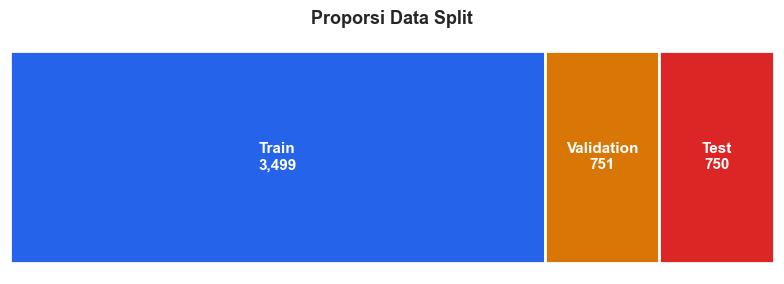

In [24]:
# === TRAIN / VAL / TEST SPLIT: 70% / 15% / 15% ===
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42  # 0.1765 dari temp ≈ 15% total
)

total = len(X)
print('=' * 45)
print('📊 DATA SPLIT')
print('=' * 45)
print(f'  Total data  : {total:,} baris')
print(f'  Train       : {len(X_train):,} baris  ({len(X_train)/total*100:.1f}%)')
print(f'  Validation  : {len(X_val):,} baris  ({len(X_val)/total*100:.1f}%)')
print(f'  Test        : {len(X_test):,} baris  ({len(X_test)/total*100:.1f}%)')
print('=' * 45)

# Visualisasi proporsi split
fig, ax = plt.subplots(figsize=(8, 3))
sizes  = [len(X_train), len(X_val), len(X_test)]
labels = [f'Train\n{len(X_train):,}', f'Validation\n{len(X_val):,}', f'Test\n{len(X_test):,}']
colors = ['#2563EB', '#D97706', '#DC2626']
left = 0
for s, l, c in zip(sizes, labels, colors):
    ax.barh(0, s, left=left, color=c, height=0.4, edgecolor='white', linewidth=2)
    ax.text(left + s/2, 0, l, ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    left += s
ax.set_xlim(0, total)
ax.axis('off')
ax.set_title('Proporsi Data Split', fontweight='bold', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## Step 5 — Training Model XGBoost

In [25]:
# === TRAINING MODEL XGBOOST (Baseline) ===
print('🚀 Melatih model XGBoost Baseline...')
print()

xgb_model = XGBRegressor(
    n_estimators     = 300,       # Jumlah pohon
    max_depth        = 6,         # Kedalaman maksimum pohon
    learning_rate    = 0.05,      # Step size (eta)
    subsample        = 0.8,       # Fraction baris per pohon
    colsample_bytree = 0.8,       # Fraction fitur per pohon
    min_child_weight = 5,         # Kontrol overfitting
    reg_alpha        = 0.1,       # L1 regularisasi
    reg_lambda       = 1.0,       # L2 regularisasi
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

# Training dengan early stopping menggunakan validation set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print('✅ Training selesai!')
print(f'   Jumlah pohon    : {xgb_model.n_estimators}')
print(f'   Kedalaman pohon : {xgb_model.max_depth}')
print(f'   Learning rate   : {xgb_model.learning_rate}')

🚀 Melatih model XGBoost Baseline...

✅ Training selesai!
   Jumlah pohon    : 300
   Kedalaman pohon : 6
   Learning rate   : 0.05


## Step 6 — Evaluasi Model

In [26]:
# === FUNGSI EVALUASI ===
def evaluate_model(model, X, y, split_name=''):
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / (y + 1e-9))) * 100
    return {'split': split_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 'y_pred': y_pred}

# Evaluasi di semua split
train_eval = evaluate_model(xgb_model, X_train, y_train, 'Train')
val_eval   = evaluate_model(xgb_model, X_val,   y_val,   'Validation')
test_eval  = evaluate_model(xgb_model, X_test,  y_test,  'Test')

print('=' * 60)
print('📊  HASIL EVALUASI MODEL XGBOOST')
print('=' * 60)
print(f'{"Metric":<12} {"Train":>12} {"Validation":>12} {"Test":>12}')
print('-' * 60)
for metric in ['MAE', 'RMSE', 'R2', 'MAPE']:
    t  = train_eval[metric]
    v  = val_eval[metric]
    te = test_eval[metric]
    if metric == 'R2':
        print(f'{metric:<12} {t:>12.4f} {v:>12.4f} {te:>12.4f}')
    elif metric == 'MAPE':
        print(f'{metric:<12} {t:>11.2f}% {v:>11.2f}% {te:>11.2f}%')
    else:
        print(f'{metric:<12} {t:>12,.0f} {v:>12,.0f} {te:>12,.0f}')
print('=' * 60)
print()
print('📖 Keterangan Metrik:')
print('   MAE  = Mean Absolute Error     → Error rata-rata (Rp)')
print('   RMSE = Root Mean Squared Error → Penalti error besar')
print('   R²   = Koefisien Determinasi   → 1.0 = sempurna')
print('   MAPE = Mean Abs Percentage Err → Error dalam persen')

📊  HASIL EVALUASI MODEL XGBOOST
Metric              Train   Validation         Test
------------------------------------------------------------
MAE                   313          558          580
RMSE                  430          810          924
R2                 1.0000       0.9999       0.9999
MAPE                0.72%        1.46%        1.11%

📖 Keterangan Metrik:
   MAE  = Mean Absolute Error     → Error rata-rata (Rp)
   RMSE = Root Mean Squared Error → Penalti error besar
   R²   = Koefisien Determinasi   → 1.0 = sempurna
   MAPE = Mean Abs Percentage Err → Error dalam persen


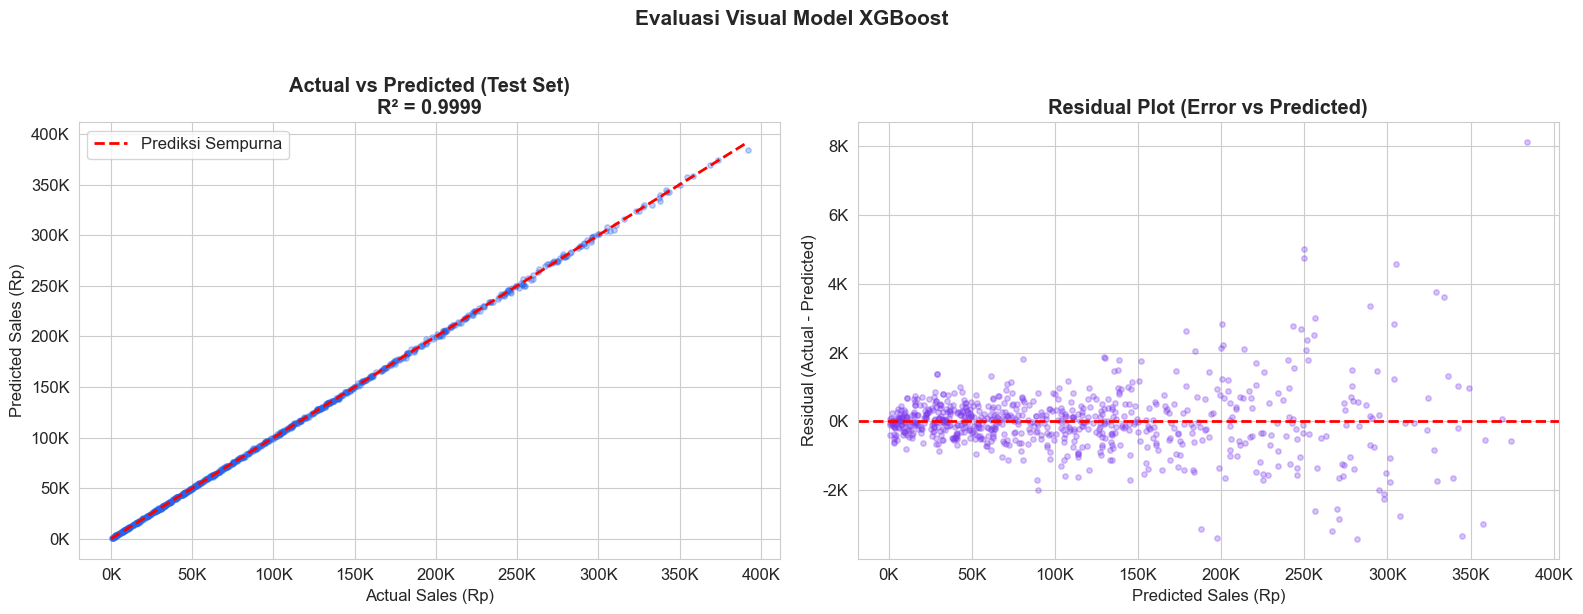

In [27]:
# === VISUALISASI: ACTUAL vs PREDICTED ===
y_test_pred = test_eval['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Actual vs Predicted
max_val = max(y_test.max(), y_test_pred.max())
axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=15, color='#2563EB')
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_title(f'Actual vs Predicted (Test Set)\nR² = {test_eval["R2"]:.4f}',
                  fontweight='bold')
axes[0].set_xlabel('Actual Sales (Rp)')
axes[0].set_ylabel('Predicted Sales (Rp)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].legend()

# Residual plot
residuals = y_test.values - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.3, s=15, color='#7C3AED')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residual Plot (Error vs Predicted)', fontweight='bold')
axes[1].set_xlabel('Predicted Sales (Rp)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Evaluasi Visual Model XGBoost', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

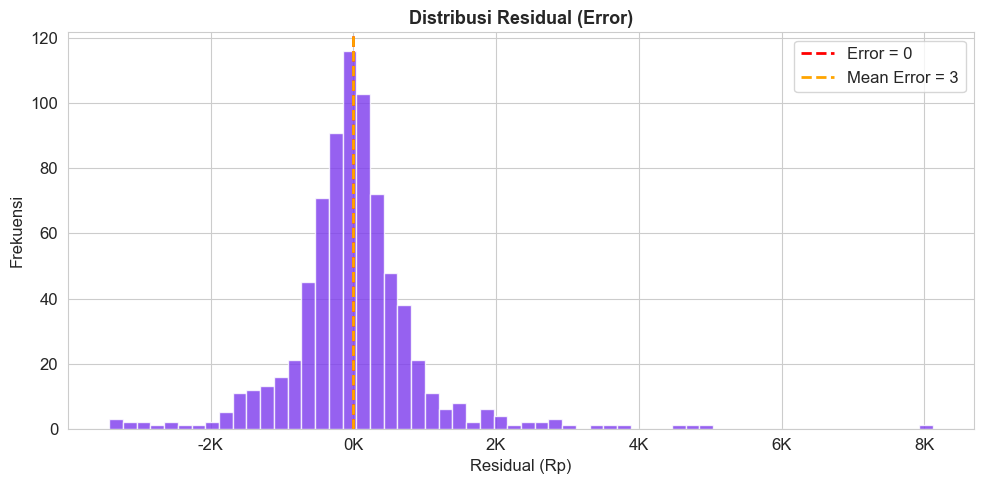

📊 Statistik Residual:
   Mean  :         2.58 Rp  (idealnya → 0)
   Std   :       923.88 Rp
   Skew  : 1.4406  (idealnya → 0)


In [28]:
# === DISTRIBUSI RESIDUAL ===
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals, bins=60, color='#7C3AED', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2, label='Error = 0')
ax.axvline(residuals.mean(), color='orange', linestyle='--', lw=2,
           label=f'Mean Error = {residuals.mean():,.0f}')
ax.set_title('Distribusi Residual (Error)', fontweight='bold', fontsize=13)
ax.set_xlabel('Residual (Rp)')
ax.set_ylabel('Frekuensi')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()

print(f'📊 Statistik Residual:')
print(f'   Mean  : {residuals.mean():>12,.2f} Rp  (idealnya → 0)')
print(f'   Std   : {residuals.std():>12,.2f} Rp')
print(f'   Skew  : {pd.Series(residuals).skew():.4f}  (idealnya → 0)')

## Step 7 — Feature Importance

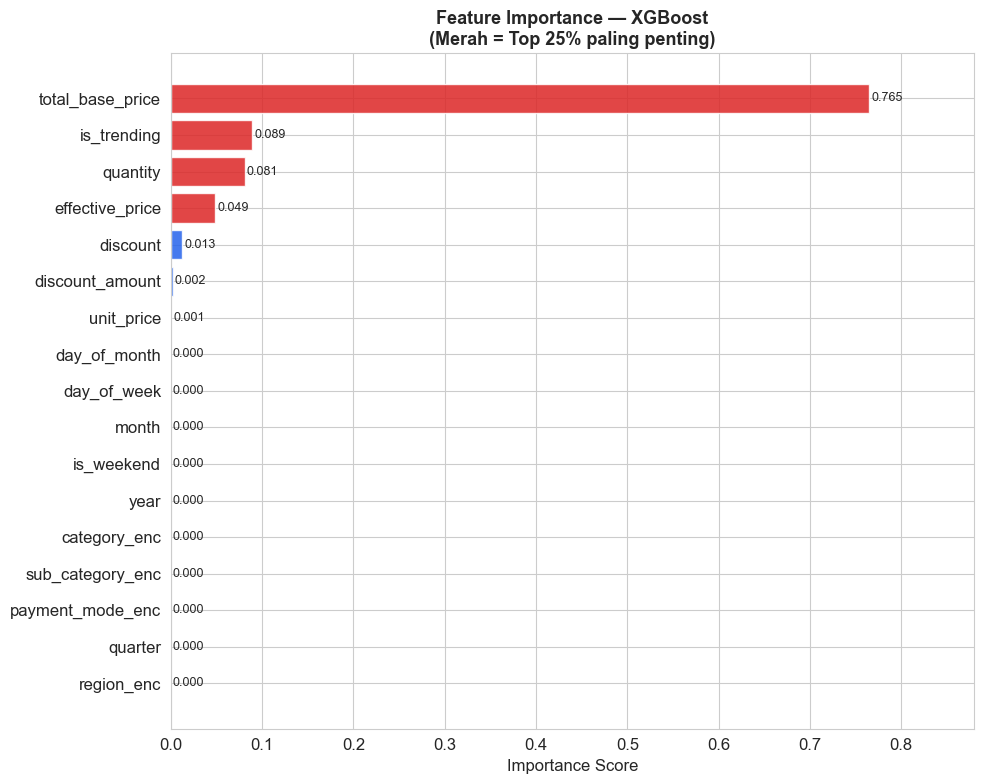


🏆 Top 5 Fitur Terpenting:
   1. total_base_price         : 0.7651
   2. is_trending              : 0.0891
   3. quantity                 : 0.0812
   4. effective_price          : 0.0489
   5. discount                 : 0.0126


In [29]:
# === FEATURE IMPORTANCE ===
importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = ['#DC2626' if imp > importance_df['importance'].quantile(0.75)
              else '#2563EB' for imp in importance_df['importance']]
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors_imp, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Feature Importance — XGBoost\n(Merah = Top 25% paling penting)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_xlim(0, importance_df['importance'].max() * 1.15)
plt.tight_layout()
plt.show()

print('\n🏆 Top 5 Fitur Terpenting:')
top5 = importance_df.sort_values('importance', ascending=False).head(5)
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f'   {i}. {row["feature"]:25s}: {row["importance"]:.4f}')

🔄 K-Fold Cross Validation (k=5)...

🔄 HASIL CROSS VALIDATION (5-Fold)
  R²   — Mean: 0.9999  ±  0.0000
  MAE  — Mean: 557 Rp  ±  17
  RMSE — Mean: 917 Rp  ±  99


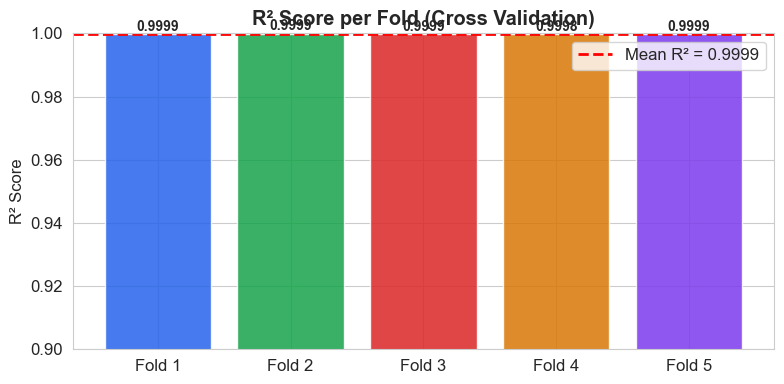

In [30]:
# === CROSS VALIDATION (K-Fold) ===
print('🔄 K-Fold Cross Validation (k=5)...')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_model = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0
)

cv_r2   = cross_val_score(cv_model, X, y, cv=kf, scoring='r2', n_jobs=-1)
cv_mae  = -cross_val_score(cv_model, X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(cv_model, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))

print()
print('=' * 55)
print('🔄 HASIL CROSS VALIDATION (5-Fold)')
print('=' * 55)
print(f'  R²   — Mean: {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}')
print(f'  MAE  — Mean: {cv_mae.mean():,.0f} Rp  ±  {cv_mae.std():,.0f}')
print(f'  RMSE — Mean: {cv_rmse.mean():,.0f} Rp  ±  {cv_rmse.std():,.0f}')
print('=' * 55)

# Plot CV R² per fold
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'Fold {i+1}' for i in range(5)], cv_r2, color=PALETTE, alpha=0.85, edgecolor='white')
ax.axhline(cv_r2.mean(), color='red', linestyle='--', lw=2, label=f'Mean R² = {cv_r2.mean():.4f}')
ax.set_title('R² Score per Fold (Cross Validation)', fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_ylim(0.9, 1.0)
ax.legend()
for i, v in enumerate(cv_r2):
    ax.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8 — Hyperparameter Tuning

In [31]:
# === HYPERPARAMETER TUNING — Manual Grid Search ===
# (Menggunakan subset untuk efisiensi)
print('🔧 Hyperparameter Tuning — mencari konfigurasi terbaik...')
print('   (Ini bisa memakan beberapa menit)\n')

param_grid = [
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1,  'subsample': 0.8},
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.9},
    {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.02, 'subsample': 0.7},
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 1.0},
]

results_tuning = []
for i, params in enumerate(param_grid):
    m = XGBRegressor(**params, colsample_bytree=0.8, min_child_weight=5,
                     reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0)
    m.fit(X_train, y_train)
    y_pred_val = m.predict(X_val)
    r2  = r2_score(y_val, y_pred_val)
    mae = mean_absolute_error(y_val, y_pred_val)
    results_tuning.append({**params, 'Val_R2': r2, 'Val_MAE': mae})
    status = '⭐ TERBAIK' if r2 == max(r['Val_R2'] for r in results_tuning) else ''
    print(f'   Config {i+1} | n_est={params["n_estimators"]:3d}, depth={params["max_depth"]}, '
          f'lr={params["learning_rate"]} → R²={r2:.4f} | MAE={mae:,.0f} {status}')

tuning_df = pd.DataFrame(results_tuning)
best_config = tuning_df.loc[tuning_df['Val_R2'].idxmax()]

print(f'\n🏆 Konfigurasi Terbaik:')
print(f'   n_estimators : {int(best_config["n_estimators"])}')
print(f'   max_depth    : {int(best_config["max_depth"])}')
print(f'   learning_rate: {best_config["learning_rate"]}')
print(f'   Val R²       : {best_config["Val_R2"]:.4f}')

🔧 Hyperparameter Tuning — mencari konfigurasi terbaik...
   (Ini bisa memakan beberapa menit)

   Config 1 | n_est=200, depth=4, lr=0.1 → R²=0.9999 | MAE=717 ⭐ TERBAIK
   Config 2 | n_est=300, depth=6, lr=0.05 → R²=0.9999 | MAE=558 ⭐ TERBAIK
   Config 3 | n_est=400, depth=6, lr=0.03 → R²=0.9999 | MAE=552 ⭐ TERBAIK
   Config 4 | n_est=500, depth=8, lr=0.02 → R²=0.9999 | MAE=512 ⭐ TERBAIK
   Config 5 | n_est=300, depth=5, lr=0.05 → R²=0.9999 | MAE=630 

🏆 Konfigurasi Terbaik:
   n_estimators : 500
   max_depth    : 8
   learning_rate: 0.02
   Val R²       : 0.9999


In [32]:
# === TRAINING MODEL FINAL (Tuned) ===
print('🚀 Training model final dengan hyperparameter terbaik...')

best_model = XGBRegressor(
    n_estimators     = int(best_config['n_estimators']),
    max_depth        = int(best_config['max_depth']),
    learning_rate    = best_config['learning_rate'],
    subsample        = best_config['subsample'],
    colsample_bytree = 0.8,
    min_child_weight = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

# Train pada gabungan Train + Validation
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
best_model.fit(X_trainval, y_trainval)

# Evaluasi final di Test Set
final_eval = evaluate_model(best_model, X_test, y_test, 'Test (Tuned)')

print('\n✅ Perbandingan Baseline vs Tuned Model:')
print('=' * 50)
print(f'{"Metric":<10} {"Baseline":>14} {"Tuned":>14}')
print('-' * 50)
for metric in ['R2', 'MAE', 'RMSE', 'MAPE']:
    b = test_eval[metric]
    t = final_eval[metric]
    arrow = '↑' if (metric == 'R2' and t > b) or (metric != 'R2' and t < b) else '↓'
    if metric == 'R2':
        print(f'{metric:<10} {b:>14.4f} {t:>14.4f}  {arrow}')
    elif metric == 'MAPE':
        print(f'{metric:<10} {b:>13.2f}% {t:>13.2f}%  {arrow}')
    else:
        print(f'{metric:<10} {b:>14,.0f} {t:>14,.0f}  {arrow}')
print('=' * 50)

🚀 Training model final dengan hyperparameter terbaik...

✅ Perbandingan Baseline vs Tuned Model:
Metric           Baseline          Tuned
--------------------------------------------------
R2                 0.9999         0.9999  ↑
MAE                   580            520  ↑
RMSE                  924            862  ↑
MAPE                1.11%          0.99%  ↑


## Step 9 — Prediksi & Interpretasi

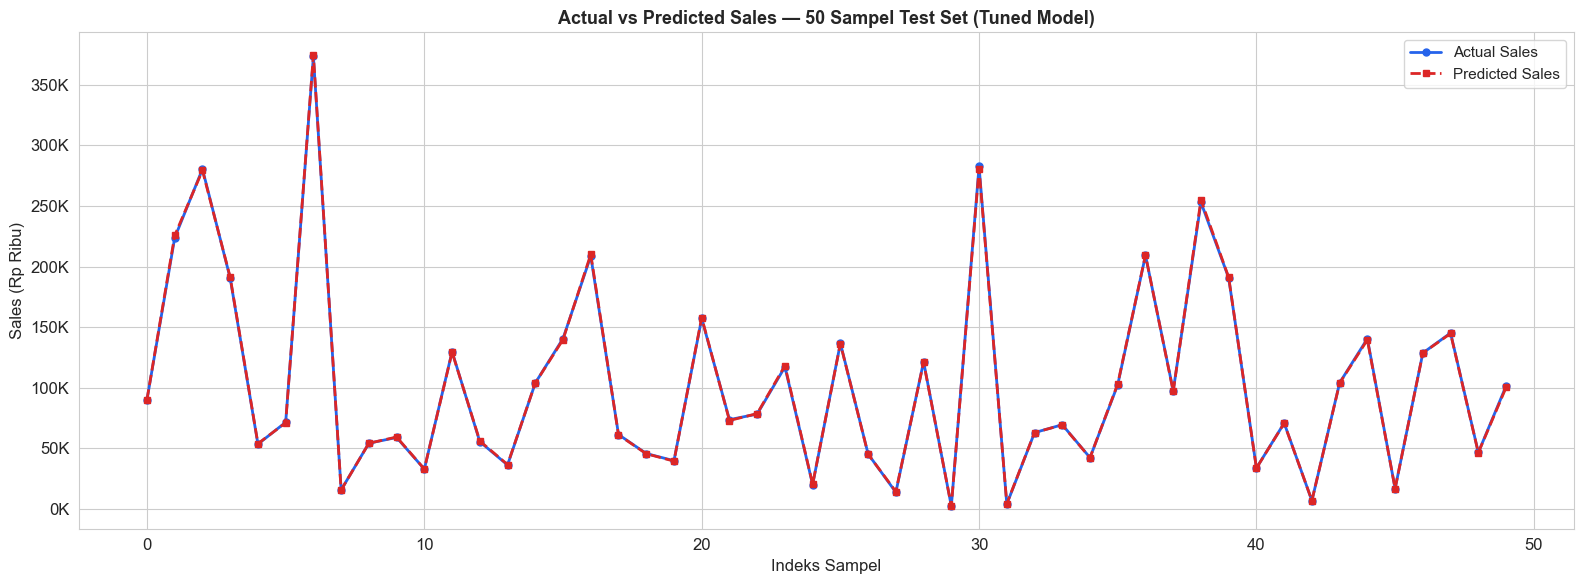

In [33]:
# === VISUALISASI PERBANDINGAN ACTUAL vs PREDICTED (FINAL MODEL) ===
y_final_pred = final_eval['y_pred']
y_actual     = y_test.values

# Ambil 50 sampel untuk visualisasi
idx = np.random.choice(len(y_actual), 50, replace=False)
idx = np.sort(idx)

fig, ax = plt.subplots(figsize=(16, 6))
x_axis = np.arange(50)
ax.plot(x_axis, y_actual[idx]/1e3,    'o-', color='#2563EB', lw=2, ms=5, label='Actual Sales')
ax.plot(x_axis, y_final_pred[idx]/1e3,'s--', color='#DC2626', lw=2, ms=5, label='Predicted Sales')
ax.fill_between(x_axis,
                y_actual[idx]/1e3,
                y_final_pred[idx]/1e3,
                alpha=0.15, color='gray')
ax.set_title('Actual vs Predicted Sales — 50 Sampel Test Set (Tuned Model)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Indeks Sampel')
ax.set_ylabel('Sales (Rp Ribu)')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
plt.tight_layout()
plt.show()

In [34]:
# === PREDIKSI DATA BARU ===
print('🔮 Contoh Prediksi Data Baru\n')

# Fungsi encode kategori
def encode_cat(col, value):
    return le_dict[col].transform([value])[0]

# Contoh transaksi baru
new_orders = [
    {
        'Deskripsi'   : 'Electronics, North, Kuantitas 3, Harga 80K, Diskon 10%',
        'quantity'    : 3,
        'unit_price'  : 80000,
        'discount'    : 10,
        'month'       : 12,
        'year'        : 2025,
        'is_trending' : 1,
        'day_of_week' : 5,
        'quarter'     : 4,
        'day_of_month': 15,
        'is_weekend'  : 1,
        'region_enc'      : encode_cat('region', 'North'),
        'category_enc'    : encode_cat('category', 'Electronics'),
        'sub_category_enc': encode_cat('sub_category', 'Rice'),  # proxy
        'payment_mode_enc': encode_cat('payment_mode', 'UPI'),
    },
    {
        'Deskripsi'   : 'Groceries, South, Kuantitas 1, Harga 30K, Diskon 5%',
        'quantity'    : 1,
        'unit_price'  : 30000,
        'discount'    : 5,
        'month'       : 3,
        'year'        : 2025,
        'is_trending' : 0,
        'day_of_week' : 2,
        'quarter'     : 1,
        'day_of_month': 7,
        'is_weekend'  : 0,
        'region_enc'      : encode_cat('region', 'South'),
        'category_enc'    : encode_cat('category', 'Groceries'),
        'sub_category_enc': encode_cat('sub_category', 'Rice'),
        'payment_mode_enc': encode_cat('payment_mode', 'COD'),
    },
]

for order in new_orders:
    desc = order.pop('Deskripsi')
    # Hitung fitur turunan
    order['effective_price']  = order['unit_price'] * (1 - order['discount'] / 100)
    order['total_base_price'] = order['unit_price'] * order['quantity']
    order['discount_amount']  = order['total_base_price'] * order['discount'] / 100

    X_new = pd.DataFrame([order])[FEATURES]
    pred  = best_model.predict(X_new)[0]
    print(f'📦 {desc}')
    print(f'   → Prediksi Sales: Rp {pred:>12,.0f}')
    print()

🔮 Contoh Prediksi Data Baru

📦 Electronics, North, Kuantitas 3, Harga 80K, Diskon 10%
   → Prediksi Sales: Rp      215,413

📦 Groceries, South, Kuantitas 1, Harga 30K, Diskon 5%
   → Prediksi Sales: Rp       28,451



In [35]:
# === RINGKASAN AKHIR ===
print('=' * 60)
print('🎯 RINGKASAN MODEL XGBOOST — REVENUE PREDICTION')
print('=' * 60)
print(f'  Dataset          : {len(df):,} transaksi e-commerce')
print(f'  Jumlah Fitur     : {len(FEATURES)} fitur')
print(f'  Split            : 70% Train / 15% Val / 15% Test')
print()
print('  Performa Final Model (Test Set):')
print(f'    R²   = {final_eval["R2"]:.4f}  ({final_eval["R2"]*100:.2f}% variance terjelaskan)')
print(f'    MAE  = Rp {final_eval["MAE"]:,.0f}')
print(f'    RMSE = Rp {final_eval["RMSE"]:,.0f}')
print(f'    MAPE = {final_eval["MAPE"]:.2f}%')
print()

if final_eval['R2'] >= 0.95:
    verdict = '🏆 EXCELLENT — Model sangat akurat!'
elif final_eval['R2'] >= 0.85:
    verdict = '✅ GOOD — Model performanya bagus'
elif final_eval['R2'] >= 0.70:
    verdict = '⚠️  FAIR — Model cukup baik, bisa ditingkatkan'
else:
    verdict = '❌ POOR — Model perlu perbaikan signifikan'
print(f'  Verdict: {verdict}')
print('=' * 60)

🎯 RINGKASAN MODEL XGBOOST — REVENUE PREDICTION
  Dataset          : 5,000 transaksi e-commerce
  Jumlah Fitur     : 17 fitur
  Split            : 70% Train / 15% Val / 15% Test

  Performa Final Model (Test Set):
    R²   = 0.9999  (99.99% variance terjelaskan)
    MAE  = Rp 520
    RMSE = Rp 862
    MAPE = 0.99%

  Verdict: 🏆 EXCELLENT — Model sangat akurat!
